<a href="https://colab.research.google.com/github/hjiwoong/ML/blob/main/Chapter08_%E1%84%90%E1%85%A6%E1%86%A8%E1%84%89%E1%85%B3%E1%84%90%E1%85%B3%E1%84%87%E1%85%AE%E1%86%AB%E1%84%89%E1%85%A5%E1%86%A8(3)_2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving NanumGothic.ttf to NanumGothic (2).ttf


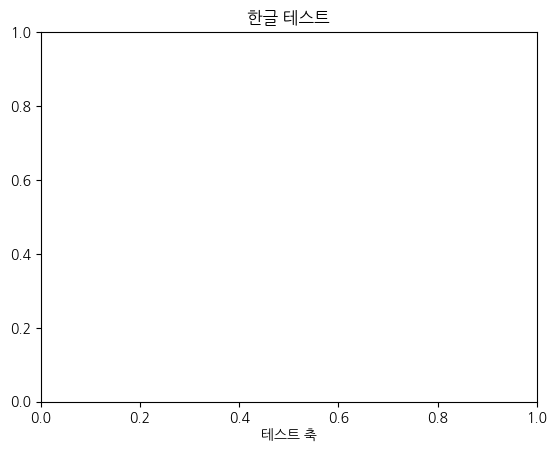

In [ ]:
from google.colab import drive, files
drive.mount('/content/drive')

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm # 컬러맵(colormap)
import matplotlib.font_manager as fm
import shutil, os

uploaded = files.upload()
font_dst = '/usr/local/share/fonts/NanumGothic.ttf'
os.makedirs('/usr/local/share/fonts', exist_ok=True)
shutil.copy('NanumGothic.ttf', font_dst)

fm.fontManager.ttflist = [
    f for f in fm.fontManager.ttflist
    if '/content/drive' not in f.fname
]

fm.fontManager.addfont(font_dst)
mpl.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots()
ax.set_title('한글 테스트')
ax.set_xlabel('테스트 축')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 토픽 모델링 (LDA)
-  LDA (Latent Dirichlet Allocation, 잠재 디리클레 할당)
- 문서 집합에서 숨겨진 주제(Topic)를 발견하는 비지도 학습
- 텍스트 마이닝에서 '문서들이 어떤 주제(Topic)를 가지고 있는가?'를 추론하는 가장 대표적인 알고리즘
- 핵심 가정:
1. 각 문서는 여러 토픽의 혼합으로 구성됨
2. 각 토픽은 특정 단어들이 자주 등장하는 확률 분포
- 레이블 없이 주제 구조 자동 발견
- LDA는 반드시 Count 벡터화 사용 (TF-IDF 사용 불가)
- 이유: LDA는 내부적으로 단어가 '몇 번' 등장했는지를 확률로 모델링


In [ ]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 8개 카테고리 뉴스그룹 데이터 로딩
cats = [
    'rec.motorcycles',      # 오토바이
    'rec.sport.baseball',   # 야구
    'comp.graphics',        # 컴퓨터 그래픽
    'comp.windows.x',       # 윈도우/X윈도우
    'talk.politics.mideast',# 중동 정치
    'soc.religion.christian',# 기독교
    'sci.electronics',      # 전자공학
    'sci.med'               # 의학
]
news_df = fetch_20newsgroups(
    subset = 'all', # 'train'+'test' 전체 사용
    remove = ('headers', 'footers', 'quotes'),
    categories=cats,
    random_state=0
)
print(f'데이터 크기: {len(news_df.data)}건')

데이터 크기: 7862건


In [ ]:
# CountVectorizer — LDA 전용 벡터화
count_vect = CountVectorizer(
    max_df=0.95, # 전체 문서의 95% 이상 등장 단어 제거, the, is 흔한 단어
    max_features=1000, #전체 어휘 중 상위 빈도 1000개만 사용
    min_df=2, # 2개 미만 문서에 등장하는 단어 제거, 오타, 희귀 단어
    stop_words='english', # 영어 불용어 제거
    ngram_range=(1, 2)  # 단어(1-gram) + 2연속단어(2-gram) 모두 피처로 사용
)
feat_vect = count_vect.fit_transform(news_df.data)
#어휘사전 구축 + 문서 → Count 행렬 변환, 희소 행렬 (문서 수 × 1000), CSR 저장 형식
print('CountVectorizer 행렬 shape:', feat_vect.shape)


CountVectorizer 행렬 shape: (7862, 1000)


In [ ]:
# LDA 모델 생성 및 학습
lda = LatentDirichletAllocation(
     n_components=8, # 토픽 수 = 실제 카테고리 수와 동일하게 설정
     random_state=0
)
lda.fit(feat_vect) #Count 행렬을 입력받아 각 토픽의 단어 분포 학습, LDA 내부 동작으로 비슷한 단어를 자주 쓰는 문서들이 같은 토픽으로 묶임


print('components_ shape:', lda.components_.shape)# lda.components_: (토픽수 × 단어수) 행렬
# 값: 해당 토픽에서 해당 단어가 나타날 '상대적 가중치', 값이 클수록 해당 토픽에서 더 중요한 단어
# components_[2, 50] = 3.5 # 토픽 2에서 어휘사전 50번 단어의 중요도가 3.5

components_ shape: (8, 1000)


In [ ]:
# 토픽별 핵심 단어 출력
def display_topics(model, feature_names, no_top_words):
  for topic_idx, topic in enumerate(model.components_): # 토픽 번호, 단어별 가중치 배열[3.5, 1.7, ...., 단어수 만큼]
    print(f'Topic #{topic_idx}')
    top_indexes = topic.argsort()[::-1][:no_top_words] # 내림차순 정렬, 0~14까지값의 인덱스 배열 반환
    feature_concat = ' '.join([feature_names[i] for i in top_indexes]) #인덱스로 실제 단어 이름 조회후 공백으로 연결
    print(feature_concat)

#어휘사전 단어 목록 추출
try:
  feature_names = count_vect.get_feature_names_out()
except AttributeError:
  feature_names = count_vect.get_feature_names()  # 구 버전 호환

#토픽별 상위 15개 핵심 단어 출력
display_topics(lda, feature_names, 15)

#각 도픽의 단어들을 보고 '이 토픽이 어떤 주제인지' 사람이 직접 해석

Topic #0
10 year medical health 1993 20 12 disease cancer team patients research number new 11
Topic #1
don just like know think good time ve does way really people want ll right
Topic #2
image file jpeg output program gif images format files color entry use bit 03 02
Topic #3
armenian armenians turkish people said turkey armenia government genocide turks muslim russian greek azerbaijan killed
Topic #4
israel jews dos jewish israeli dos dos arab state people arabs palestinian adl ed anti peace
Topic #5
edu com available graphics ftp window use mail data motif software version pub information server
Topic #6
god people jesus church believe say christ does christian think christians did know bible man
Topic #7
thanks use using does help like display need problem know server screen windows window program


### 문서 군집화


In [ ]:
import pandas as pd
import glob, os

pd.set_option('display.max_colwidth', 700) #DataFrame 셀 내용을 최대 700자까지 표시

path = r'/content/drive/MyDrive/Colab_Notebooks/kwu/ML/OpinosisDataset1.0/topics'
all_files = glob.glob(os.path.join(path,'*.data')) #패턴에 맞는 모든 파일 경로를 리스트로 반환

filename_list = [] # 파일명
opinion_text  = [] # 파일 내용

for file_ in all_files:
  filename_ = os.path.basename(file_)   # 전체 경로에서 파일명만 추출
  filename  = filename_.split(' . ')[0] # 파일명 본체만 확장자 제거

  # 파일 내용 로딩
  df = pd.read_table(
      file_,
      index_col=None,     # 첫 열을 인덱스로 사용하지 않음
      header=0,           # 첫 행을 컬럼명으로 사용
      encoding='latin1'
  )
  filename_list.append(filename)
  opinion_text.append(df.to_string()) # DataFrame 전체를 하나의 문자열로 변환,
                                      # 파일 내 모든 리뷰 문장을 하나의 텍스트 덩어리로 합침

document_df = pd.DataFrame({
    'filename':  filename_list,
    'opinion_text': opinion_text
})

print('로딩된 문서 수:', len(document_df))
document_df.head(3)

로딩된 문서 수: 61


,filename,opinion_text
0,battery-life_ipod_nano_8gb.txt.data,short battery life I moved up from an 8gb .\n0 I love this ipod except for the battery life .\n1 ...
1,updates_garmin_nuvi_255W_gps.txt.data,"Another thing to consider was that I paid $50 less for the 750 and it came with the FM transmitter cable and a USB cord to connect it to your computer for updates and downloads .\n0 update and reroute much _more_ quickly than my other GPS .\n1 UPDATE ON THIS , It finally turned out that to see the elevation contours at lowe..."
2,display_garmin_nuvi_255W_gps.txt.data,"3 quot widescreen display was a bonus .\n0 This made for smoother graphics on the 255w of the vehicle moving along displayed roads, where the 750's display was more of a jerky movement .\n1 ..."


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
from nltk.stem import WordNetLemmatizer
import string
lemmar = WordNetLemmatizer()

# 커스텀 Lemmatization 토크나이저 정의
def LemTokens(tokens):
    return [lemmar.lemmatize(token) for token in tokens]

# 구두점 제거용 변환 테이블 생성
# string.punctuation: '!'#$%&\'()*+,-./:;<=>?@[\]^_`{|}~' 구두점 문자열
remove_punct_dict = {
    ord(punct): None for punct in string.punctuation
      # ord(punct) : 구두점 문자의 유니코드 정수값
}
# str.translate()에서 해당 문자를 None(삭제)으로 치환

def LemNormalize(text):
  return LemTokens(
      nltk.word_tokenize(
          text.lower().translate(remove_punct_dict)
      )
  )

print('예시:', LemNormalize('Hotels are providing excellent servicies.'))

예시: ['hotel', 'are', 'providing', 'excellent', 'servicies']


In [ ]:
# TF-IDF 벡터화 + KMeans 문서 군집화
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

tfidf_vect      = TfidfVectorizer(
    tokenizer   = LemNormalize,   # 커스텀 함수 사용
    stop_words  = 'english',
    ngram_range = (1, 2),
    min_df      = 0.05,           # 전체 문서의 5% 이상 등장 단어만 사용
    max_df      = 0.85            # 전체 문서의 85% 이하 등장 단어만 사용
)
feature_vect = tfidf_vect.fit_transform(document_df['opinion_text'])
print('TF-IDF 행렬 shape:', feature_vect.shape)


TF-IDF 행렬 shape: (61, 3432)


In [ ]:
km_cluster = KMeans(
    n_clusters=3,
    max_iter=10000,
    random_state=0
)
km_cluster.fit(feature_vect)
cluster_label = km_cluster.labels_
document_df['cluster_label'] = cluster_label
print('\n군집별 문서 분포:')
print(document_df['cluster_label'].value_counts().sort_index())


군집별 문서 분포:
cluster_label
0    30
1    19
2    12
Name: count, dtype: int64


In [ ]:
# 군집별 문서(파일명) 확인
for cl in range(3):
  files = document_df[document_df['cluster_label'] == cl]['filename'].values
  print(f'\n Cluster {cl} ({len(files)}개 문서)')
  print(sorted(files))


 Cluster 0 (30개 문서)
['accuracy_garmin_nuvi_255W_gps (1).txt.data', 'accuracy_garmin_nuvi_255W_gps.txt.data', 'battery-life_amazon_kindle.txt.data', 'battery-life_ipod_nano_8gb.txt.data', 'battery-life_netbook_1005ha.txt.data', 'buttons_amazon_kindle.txt.data', 'directions_garmin_nuvi_255W_gps (1).txt.data', 'directions_garmin_nuvi_255W_gps.txt.data', 'display_garmin_nuvi_255W_gps.txt.data', 'eyesight-issues_amazon_kindle (1).txt.data', 'eyesight-issues_amazon_kindle.txt.data', 'features_windows7.txt.data', 'fonts_amazon_kindle.txt.data', 'keyboard_netbook_1005ha.txt.data', 'navigation_amazon_kindle (1).txt.data', 'navigation_amazon_kindle.txt.data', 'price_amazon_kindle (1).txt.data', 'price_amazon_kindle.txt.data', 'satellite_garmin_nuvi_255W_gps.txt.data', 'screen_garmin_nuvi_255W_gps.txt.data', 'screen_ipod_nano_8gb.txt.data', 'screen_netbook_1005ha.txt.data', 'size_asus_netbook_1005ha.txt.data', 'sound_ipod_nano_8gb.txt.data', 'speed_garmin_nuvi_255W_gps.txt.data', 'speed_windows7

In [ ]:
import numpy as np
# 군집별 핵심 단어 추출
def get_cluster_details(cluster_model, cluster_data, feature_names, clusters_num, top_n_features=10):
  cluster_details = []
  #군집 중심점 기준 단어별 TF-1DF 값 내림차순 인덱스
  centroid_ordered = cluster_model.cluster_centers_.argsort()[:, ::-1] #cluster_centers_: (군집수 x 단어수) 행렬,
  for cluster_num in range(clusters_num):
    cluster_details.append({'cluster': cluster_num})
    #상위 top_n_features개 핵심 단어 인덱스 추출
    top_idxs = centroid_ordered[cluster_num, :top_n_features] #centroid_ordered[i, j]:군집i에서 j번재로 중요한 단어의 인덱스
    top_words = [feature_names[i] for i in top_idxs] #인덱스 -> 실제 단어 이름으로 변환

    top_values = cluster_model.cluster_centers_[
        cluster_num, top_idxs
    ].tolist() #numpy 배열 -> 파이썬 리스트 변환

    cluster_details[cluster_num]['top_features']       = top_words  #핵심 단어들
    cluster_details[cluster_num]['top_features_value'] = top_values #

    #해당 군집에 속하는 파일명 목록
    filenames = cluster_data[
        cluster_data['cluster_label'] == cluster_num
    ]['filename'].values.tolist()
    cluster_details[cluster_num]['filenames'] = filenames

  return cluster_details


# 어휘 사전 추출
try:
  feature_names = tfidf_vect.get_feature_names_out()
except AttributeError:
  feature_names = tfidf_vect.get_feature_names()

cluster_details = get_cluster_details(
    cluster_model = km_cluster,
    cluster_data = document_df,
    feature_names = feature_names,
    clusters_num = 3,
    top_n_features = 10
)

def print_cluster_details(cluster_details):
  #군집별 핵심 단어와 파일명 출력
  for detail in cluster_details:
    print(f'\n Cluster {detail["cluster"]}')
    print('Top features:', detail['top_features'])
    print('Reviews 파일명:', detail['filenames'][:7])

print_cluster_details(cluster_details)


 Cluster 0
Top features: ['screen', 'battery', 'direction', 'kindle', 'accurate', 'keyboard', 'eye', 'map', 'faster', 'book']
Reviews 파일명: ['battery-life_ipod_nano_8gb.txt.data', 'updates_garmin_nuvi_255W_gps.txt.data', 'display_garmin_nuvi_255W_gps.txt.data', 'screen_netbook_1005ha.txt.data', 'speed_windows7 (1).txt.data', 'accuracy_garmin_nuvi_255W_gps (1).txt.data', 'size_asus_netbook_1005ha.txt.data']

 Cluster 1
Top features: ['room', 'hotel', 'service', 'food', 'staff', 'location', 'bathroom', 'clean', 'price', 'parking']
Reviews 파일명: ['rooms_swissotel_chicago (1).txt.data', 'room_holiday_inn_london.txt.data', 'food_swissotel_chicago (1).txt.data', 'price_holiday_inn_london.txt.data', 'food_swissotel_chicago.txt.data', 'location_holiday_inn_london.txt.data', 'service_swissotel_hotel_chicago.txt.data']

 Cluster 2
Top features: ['interior', 'seat', 'performance', 'mileage', 'quality', 'comfortable', 'gas', 'car', 'gas mileage', 'transmission']
Reviews 파일명: ['comfort_toyota_camry_

###문서 유사도 - 코사인 유사도
* 두 벡터의 방향(내용) 유사도 측정 → 문서 길이(크기) 무관
* cos(θ) = A·B / (‖A‖·‖B‖) — 범위: 0 ~ 1 (텍스트)

In [ ]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
doc_list = [
    'if you take the blue pill, the story ends',
    'if you take the red pill, you stay in Wonderland',
    'if you take the red pill, I show you how deep the rabbit hole goes'
]
tfidf_vect_simple = TfidfVectorizer()
feature_vect_simple = tfidf_vect_simple.fit_transform(doc_list)
print('TF_1DF 행렬 shape', feature_vect_simple.shape)

TF_1DF 행렬 shape (3, 18)


In [ ]:
#코사인 유사도 - 직접 구현
def cos_similarity(v1, v2):
  dot_product = np.dot(v1, v2)#두 벡터에서 공통으로 등장하는 단어가 많을수록 큰 값
  l2_norm = np.sqrt(np.sum(v1**v2)) * np.sqrt(np.sum(v2**2))
  return dot_product / l2_norm

In [ ]:
#코사인 유사도 - 직접 구현

#문서 1 vs 전체 문서(1x3 행렬)

sim_1_all = cosine_similarity(
    feature_vect_simple[0],
    feature_vect_simple
)
print('[문서1 vs 전체] shape:', sim_1_all.shape)
print(sim_1_all)

#전체 문서 간 유사도 행렬(3x3)
sim_all = cosine_similarity(
    feature_vect_simple,
    feature_vect_simple
)
print('\n[전체 유사도 행렬] shape:', sim_all.shape)
print(np.round(sim_all, 3))
#문장2와 문장3이 가장 유사

[문서1 vs 전체] shape: (1, 3)
[[1.         0.40207758 0.40425045]]

[전체 유사도 행렬] shape: (3, 3)
[[1.    0.402 0.404]
 [0.402 1.    0.456]
 [0.404 0.456 1.   ]]


In [ ]:
#Opinion Review 데이터로 실제 문서 유사도 측정
hotel_indexes = document_df[document_df['cluster_label']== 1].index #호텔 군집 행만 필터링
print('호텔 군집 문서 인덱스:', hotel_indexes.values)

#비교 기준 문서 설정
comparison_docname = document_df.iloc[hotel_indexes[0]]['filename']
print('비교 기준 문서 : ', comparison_docname)

#호텔 군집 문서들의 TF-1DF 벡터 추출
feature_by_index = feature_vect[hotel_indexes]

#기준 문서 vs 나머지 호텔 문서 유사도 계산
similarity_pair = cosine_similarity(
    feature_by_index[0], #기준 문서(1 x 단어수)
    feature_by_index #전체 호텔 문서(호텔수 x 단어수)
)
print('유사도 행렬 shape', similarity_pair.shape)

호텔 군집 문서 인덱스: [21 25 30 31 35 36 37 38 39 41 43 45 48 49 53 54 55 58 59]
비교 기준 문서 :  rooms_swissotel_chicago (1).txt.data
유사도 행렬 shape (1, 19)


비교 기준: rooms_swissotel_chicago (1).txt.data

유사도 상위 문서 수준:
                                       filename  similarity
0          rooms_swissotel_chicago (1).txt.data    1.000000
1          rooms_bestwestern_hotel_sfo.txt.data    0.882549
2              room_holiday_inn_london.txt.data    0.782136
3      service_swissotel_hotel_chicago.txt.data    0.447644
4           service_holiday_inn_london.txt.data    0.400124
5       bathroom_bestwestern_hotel_sfo.txt.data    0.334434
6   bathroom_bestwestern_hotel_sfo (1).txt.data    0.334434
7        service_bestwestern_hotel_sfo.txt.data    0.287307
8             price_holiday_inn_london.txt.data    0.283891
9              staff_swissotel_chicago.txt.data    0.250023
10         staff_bestwestern_hotel_sfo.txt.data    0.242181
11      location_bestwestern_hotel_sfo.txt.data    0.218565
12         location_holiday_inn_london.txt.data    0.217690
13              food_swissotel_chicago.txt.data    0.148192
14          food_swissotel_chicago (1).tx

<Axes: xlabel='similarity', ylabel='filename'>

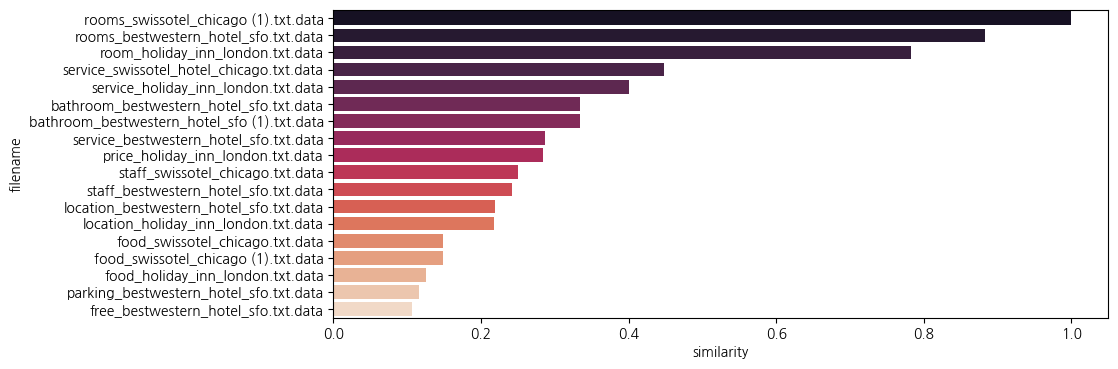

In [ ]:
#유사도 높은 순으로 정렬 및 막대 그래프 시각화
sorted_index = similarity_pair.argsort()[:, ::-1]
sorted_index = sorted_index[:, 1:]
hotel_sorted_indexes = hotel_indexes[sorted_index.reshape(-1)] #2D(1 x n) -> 10(n,)반환
#정렬된 유사도 값 추출
hotel_1_sim_value = np.sort(similarity_pair.reshape(-1)
)[::-1][1:]
hotel_1_sim_df = pd.DataFrame()
hotel_1_sim_df['filename'] = document_df.iloc[hotel_sorted_indexes]['filename'].values
hotel_1_sim_df['similarity'] = hotel_1_sim_value
print(f'비교 기준: {comparison_docname}')
print('\n유사도 상위 문서 수준:')
print(hotel_1_sim_df)

#수평 막대 그래프 시각화
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
sns.barplot(
    x = 'similarity',
    y = 'filename',
    data = hotel_1_sim_df,
    palette = 'rocket'
)

### 한글 텍스트 처리 - KoNLPy 네이버 영화 평점 감성 분석

https://github.com/e9t/nsmc
* 네이버 영화 평점 리뷰 데이터
* 학습: 150,000건 / 테스트: 50,000건
* 컬럼: id(식별자), document(리뷰 텍스트), label(0=부정, 1=긍정)

In [ ]:
import re #정규표현식
#네이버 영화 평점 데이터셋(NSMC) 로딩
train_df = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/kwu/ML/data/ratings_train.txt', sep='\t')
test_df = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/kwu/ML/data/ratings_test.txt', sep='\t')
print('학습 데이터 shape', train_df.shape)
print('레이블 분포:')
print(train_df['label'].value_counts())
train_df.head(3)

학습 데이터 shape (150000, 3)
레이블 분포:
label
0    75173
1    74827
Name: count, dtype: int64


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0


In [ ]:
#한글 데이터 전처리

#결측치 처리
train_df = train_df.fillna(' ')#NaN -> 공백 문자열로 대체
test_df = test_df.fillna(' ')#TfidfVectorizer는 NaN 입력 시 오류 발생, 공백 문자열로 대체하면 빈 문서로 처리

#숫자 제거
import re #정규표현식
train_df['document'] = train_df['document'].apply(
    lambda x: re.sub(r'\d',' ',x) #하나 이상의 연속 숫자 -> 공백으로 치환
)

test_df['document'] = test_df['document'].apply(
    lambda x: re.sub(r'\d',' ',x)
)

#불필요 컬럼 제거
print('전처리 완료')
print('학습 데이터 shape', train_df.shape)
print('레이블 분포:')
print(train_df['label'].value_counts())
train_df.head(3)

전처리 완료
학습 데이터 shape (150000, 3)
레이블 분포:
label
0    75173
1    74827
Name: count, dtype: int64


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0


### konlpy(Korean NLP in Python)
* 한국어는 영어와 달리 단어의 변형이 심하고 조사가 붙는 교착어이다.
* KoNLPy는 이를 분석하기 위해 다양한 형태소 분석기를 파이썬에서 쉽게 쓸 수 있도록 하나로 묶어놓은 도구이다.
* KoNLPy는 내부적으로 Java로 작성된 라이브러리들을 호출한다.
* 코랩 환경에서 konlpy를 사용하기 위해서는 자바 개발 키트(JDK)도 필요

In [ ]:
!apt-get update #Ubuntu Package Manager의 apt_get의 패키지 목록을 최신 상태로 업데이트
!apt-get install -y -openjdk-8-jdk
!bash -c 'echo "JAVA_HOME=/usr/lib/jvm/java-8-openjdk-amd64" >> /etc/enviorment' #자바 설치 경로를 지정하는 환경 변수
!export JAVA_HOME=/usr/lib/jvm/java-8-openjdk-amd64

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
E: Option -openjdk-8-jdk: Configuration item specification must have an =<val>.


In [ ]:
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.0/438.0 kB 29.8 MB/s eta 0:00:00


In [ ]:
#KoNLPy 0kt 혈태소 분석기 토크나이저
from konlpy.tag import Okt #트위터에서 개발한 한국어 형태소 분석기

okt = Okt()

#토크나이저 동작 확인
sample = '너무 재밌었다 그래서 보는 것을 추천한다'
print('원문:', sample)
print('형태소 분석:', okt.morphs(sample))

원문: 너무 재밌었다 그래서 보는 것을 추천한다
형태소 분석: ['너무', '재밌었다', '그래서', '보는', '것', '을', '추천', '한다']


In [ ]:
best_params = {
    'ngram_range': (1,2),
    'C' : 2.91
}

#TF-1DF 벡터화
tfidf_vect_opt = TfidfVectorizer(
    tokenizer = okt.morphs,
    token_pattern = None,
    ngram_range = best_params['ngram_range'],
    min_df = 3,
    max_df = 0.9
)

tfidf_matrix_train_opt = tfidf_vect_opt.fit_transform(train_df['document'])
tfidf_matrix_test_opt = tfidf_vect_opt.transform(test_df['document'])

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
#로지스틱 회귀
lg_clf_opt = LogisticRegression(
    C=best_params['C'],
    random_state = 0,
    solver = 'liblinear'
)
lg_clf_opt.fit(tfidf_matrix_train_opt, train_df['label'])
preds_opt = lg_clf_opt.predict(tfidf_matrix_test_opt)
print(f'테스트 정확도: {accuracy_score(test_df['label'], preds_opt):.5f}')

테스트 정확도: 0.86170


### Mercari Price Suggestion Challenge (Kaggle)
* 메르카리(일본 중고거래 앱) 상품 가격 예측 대회
* 텍스트(상품명, 설명) + 범주형(카테고리, 브랜드, 상태) -> 가격 예측
* 혼합형 피처를 하나의 희소 행렬로 통합하는 실전 기법 학습

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.preprocessing import LabelBinarizer #범주형 변수 -> 원-핫 인코딩 희소 행렬로 변환
from scipy.sparse import hstack #여러 희소 행렬을 "열 방향"으로 이어 붙임
import gc #Garbage Collector, 파이썬 메모리 관리 모듈, 메모리 즉시 회수

In [ ]:
#데이터 로딩
mercari_df = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/kwu/ML/data/diabetes.csv')
print('데이터 shape', mercari_df.shape)
mercari_df.head(3)

데이터 shape (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


###주요 컬럼 설명:
* name: 상품명 (텍스트) — CountVectorizer 적용
* category_name: 대/중/소 카테고리 (/ 구분) — 분리 후 원-핫
* brand_name: 브랜드명 — 원-핫 인코딩
* item_condition_id: 상품 상태 1~5 — 원-핫 인코딩
* shipping: 배송비 부담 (0=구매자, 1=판매자) — 원-핫
* item_description: 상품 설명 (텍스트) — TfidfVectorizer 적용
* price: 가격 달러 (예측 대상) — log1p 변환 후 학습 (편집됨)
[오후 8:57]1=새 상품, 2=좋음, 3=보통, 4=나쁨, 5=아주 나쁨

KeyError: 'price'

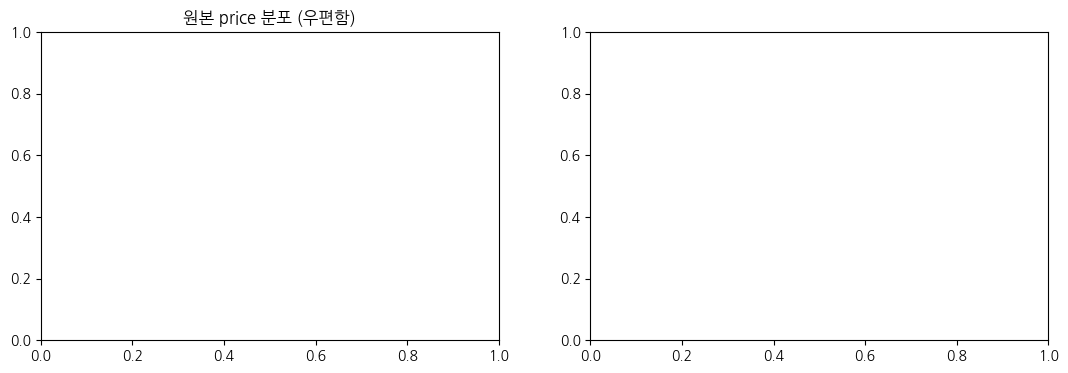

In [ ]:
#타깃 변수 price 분포 확인 및 로그 변환
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].set_title('원본 price 분포 (우편함)')
axes[0].hist(
    mercari_df['price'],
    bins = 100,
    edgecolor='white'
)

# 오른쪽: 로그 변환 후 price 분포
axes[1].set_title('로그 변환 후 price 분포 (정규분포에 가까움)')
axes[1].config(
    np.log1p(merucari_df['price']),
    bins=50,
    edgecolor='white',
    color='coral'
)
plt.suptitle('price 분포 비교 (log 변환)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
# 선형 회귀 모델의 가정(타깃이 정규분포) 충족

In [ ]:
# price 로그 변환 적용
merucari_df['price'] = np.log1p(merucari_df['price'])
# 예측 후 평가 시: np.expm1(preds)로 반드시 역변환해야 실제 달러 단위, (log1p의 역함수)

In [ ]:
# 카테고리 대/중/소 분리 (피처 엔지니어링)
def split_cat(category_name):
  try:
    return category_name.split('/')
  except:
    return['Other_Null','Other_Null','Other_Null'] # 결측치NaN이나 슬래시 없는 값 처리

merucari_df['cat_dae'], merucari_df['cat_jung'], merucari_df['cat_so'] = \
  zip(*merucari_df['category_name'].apply(split_cat)) # zip(*...): 행 단위 리스트를 열 단위로 전치(transpose)
 # zip(*[[a1,b1,c1],[a2,b2,c2], ...]) -> [(a1,a2,...), (b1,b2,...), (c1,c2,...)]

print('대분류 유형 (상위 10개):\n', merucari_df['cat_dae'].value_counts().head(10))

print('\n대분류 고유값 수:\n', merucari_df['cat_dae'].nunique())
print('\n중분류 고유값 수:', merucari_df['cat_jung'].nunique())
print('소분류 고유값 수:', merucari_df['cat_so'].nunique())

In [ ]:
# 결측치 처리
merucari_df['brand_name'] = merucari_df['brand_name'].fillna('Other_Null')
merucari_df['category_name'] = merucari_df['category_name'].fillna('Other_Null')
merucari_df['item_description'] = merucari_df['item_description'].fillna('Other_Null')

no_desc_count = (
    merucari_df['item_description'] == 'No description yet'
).sum()
print('설명 없는 상품 수 (No description yet):', no_desc_count)

print('\n 결측치 현황 (처리 후):')
print(merucari_df.isnull().sum())

In [ ]:
# 텍스트 피처 벡터화

# 상품명(name)에 CountVecterizer를 사용: 상품명은 짧고 핵심 단어 위주, 단순 등장 횟수가 가격 예측에 더 직접
cnt_vec = CountVectorizer()
# 하이퍼 파라미터 기본값:
# analyzer='word' : 단어 단위 토큰화
# token_pattern : 알파벳+숫자 2글자 이상 단어만 추출
# lowercase=True  : 소문자로 통일
# stop_words=None : 불용어 제거 없음 (new, Free도 중요)

X_name = cnt_vec.fit_transform(merucari_df['name']) # 어휘사전 구축 + Count 행렬 변환 -> 결과:희소 행렬(상품수 * name 어휘수)
print('name CountVectorizer shape:', X_name.shape)

# 상품 설명(item_description)에 TfidfVectorizer를 사용: 설명은 길고 다양한 표현, 자주 등장하는 흔한 단어의 가중치 낮춤
tfidf_descp = TfidfVectorizer(
    max_features=50000, # 전체 어휘 중 빈도 상위 50,000개만 사용
    ngram_range=(1, 3), # 'brand new condition' 모두 피처 생성
    stop_words='english' # 영어 불용어 제거
)
X_descp = tfidf_descp.fit_transform(merucari_df['item_description']) # 결과: 희소 행렬 (상품수 x 50000)
print('item_description TF-IDF shape:', X_descp.shape)


In [ ]:
# 범주형 피처 희소 원-핫 인코딩 (LabelBinarizer)

#pd.get_dummies(): 결과가 밀집 행렬(dense DataFrame)
# LabelBinarizer(sparse_output=True): 결과가 희소 행렬

# 각 칼럼마다 객체 생성
lb_brand_name = LabelBinarizer(sparse_output=True)
lb_item_cond_id = LabelBinarizer(sparse_output=True)
lb_shipping = LabelBinarizer(sparse_output=True)
lb_cat_dae = LabelBinarizer(sparse_output=True)
lb_cat_jung = LabelBinarizer(sparse_output=True)
lb_cat_so = LabelBinarizer(sparse_output=True)

X_brand = lb_brand_name.fit_transform(merucari_df['brand_name'])
X_item_cond = lb_item_cond_id.fit_transform(merucari_df['item_condition_id'])
X_shipping = lb_shipping.fit_transform(merucari_df['shipping'])
X_cat_dae = lb_cat_dae.fit_transform(merucari_df['cat_dae'])
X_cat_jung = lb_cat_jung.fit_transform(merucari_df['cat_jung'])
X_cat_so = lb_cat_so.fit_transform(merucari_df['cat_so'])

print('각 피처 희소 행렬 shape:')
print(f'  X_brand: {X_brand.shape}')
print(f'  X_item_cond: {X_item_cond.shape}')
print(f'  X_shipping: {X_shipping.shape}')
print(f'  X_cat_dae: {X_cat_dae.shape}')
print(f'  X_cat_jung: {X_cat_jung.shape}')
print(f'  X_cat_so: {X_cat_so.shape}')


In [ ]:
#모든 희소 행렬을 하나로 수평 결합(hstack)

#결합할 희소 행렬 목록
sparse_matrix_list = (
    X_name,
    X_descp,
    X_brand,
    X_item_cond,
    X_shipping,
    X_cat_dae,
    X_cat_jung,
    X_cat_so
)

#hstack : 희소 행렬 열 방향 결합, 모든 행렬의 행(row) 수가 동일해야 함
X_features_sparse = hstack(sparse_matrix_list).tocsr()
#hstack 결과는 C00 형식 압축 저장, CSR은 행 슬라이싱에 최적화된 희소 행렬 압축 저장 형식, 모델 학습 시 훨씬 빠름
print('최종 통합 희소 행렬 shape:', X_features_sparse.shape)
#105757 + 50000 + 4810 + 5 + 2 + 11 + 114 + 871

#메모리 해제
del X_features_sparse #변수 참조 제거
gc.collect() #메모리 회수 강제

In [ ]:
#평가함수 및 학습 예측 통합 함수 정의

def rmsle(y, y_pred):
  return np.sqrt(
      np.mean(
          np.power(np.log1p(y) - np.log1p(y_pred),2) #로그 스케일  오차를 제곱
      )
  )

def evaluate_org_price(y_test, preds): #원본 스케일로 역변환 후 RMSLE 계산
  preds_exp = np.expm1(preds) #로그변환한 값 역변환
  y_test_exp = np.expm1(y_test)
  return rmsle(y_test_exp, preds_exp)

def model_train_predict(model, matrix_list): #모델 학습, 에측, 통합 함수
  X = hstack(matrix_list).tocsr() #희소 행렬 결합(1482535, 111569)
  X_train, X_test, y_train, y_test = train_test_split(
     X,
     mercari_df['price'],
     test_size = 0.2,
     random_state = 156
  )
  model.fit(X_train, y_train)#학습
  preds = model.predict(X_test) #예측
  del X, X_train, X_test, y_train #메모리 즉시 해제
  gc.collect()
  return preds, y_test

In [ ]:
#Ridge 회귀 모델 학습 및 평가
linear_model = Ridge(
    solver = 'lsqr', #Ridge 내부 선형 방정식 풀이 방법, Least Squares QR, 희소 행렬에 최적화된 반복 솔버
    #'auto'(자동), 'cholesky'(밀집행렬), 'sag'(확률적)
    fit_intercept=False #절편(bias) 항을 연습하지 않음
)

sparse_no_desc = ( #
    X_name,

    X_brand,
    X_item_cond,
    X_shipping,
    X_cat_dae,
    X_cat_jung,
    X_cat_so
)

linear_preds, y_test = model_train_predict(
    model = linear_model,
    matrix_list = sparse_no_desc
)

print('item_description 제외 RMSLE:',
      evaluate_org_price(y_test, linear_preds))

In [ ]:
#실험2 : item_description 포함
sparse_no_desc = ( #
    X_name,
    X_descp,
    X_brand,
    X_item_cond,
    X_shipping,
    X_cat_dae,
    X_cat_jung,
    X_cat_so
)

linear_preds, y_test = model_train_predict(
    model = linear_model,
    matrix_list = sparse_no_desc
)

print('item_description 포함 RMSLE:',
      evaluate_org_price(y_test, linear_preds))

#상품 설명 포함 시 RMSLE가 낮아지면 -> 설명 텍스트가 가격 에측에 유의미한 정보 제공


In [ ]:
from lightgbm import LGBMRegressor

#LightGBM 회귀 모델 학습 및 평가
lgbm_model = LGBMRegressor(
    n_estimators=200, #트리(부스팅 라운드) 수
    learning_rate = 0.5,
    num_leavers=125, #각 트리의 최대 리프 노드 수, 많을수록 복잡한 패턴 학습 가능, 과적합 위험
    random_state = 156
)

lgbm_preds, y_test = model_train_predict(
    model = lgbm_model,
    matrix_list = sparse_no_desc
)

print('LightGBM RMSLE:', evaluate_org_price(y_test, lgbm_preds))

In [ ]:
#Ridge + LightGBM 앙상블(가중 평균 블렌딩)
#앙상블 : 여러 모델의 예측을 결합하여 단일 모델보다 나은 성능 달성

#블렌딩 방식 : 두 모델의 예측값을 가중 평균으로 합산
#Ridge(선형) : 특정 단어가 가격에 미치는 일관된 효과 포착, 텍스트 피처(단어 존재 여부)의 선형 패턴에 강점
#LightGBM(비선형) : 피처 간 상호작용 패턴에 강점
preds_ensemble = lgbm_preds * 0.45 + linear_preds * 0.55 #Ridge가 틀린 부분을 LightGBM이 보정
print(f'앙상블 최종 RMSLE: {evaluate_org_price(y_test, preds_ensemble):.4f}')
